In [48]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [49]:
! pip install dagshub mlflow

# Dagshub/Mlflow initialization

In [50]:
import dagshub
import mlflow
import mlflow.sklearn
import os

TOKEN = '773e6d0f45f4f8c8ed729b693f548555a4de31f8'

os.environ['DAGSHUB_USER_TOKEN'] = TOKEN
dagshub.auth.add_app_token(TOKEN)

dagshub.init(repo_owner='sbolk23', repo_name='IEEE-CIS-Fraud-Detection-Kaggle-Competition', mlflow=True)

The added token already exists in the token cache, skipping


Initialized MLflow to track repo "sbolk23/IEEE-CIS-Fraud-Detection-Kaggle-Competition"

Repository sbolk23/IEEE-CIS-Fraud-Detection-Kaggle-Competition initialized!

In [51]:
TARGET = 'isFraud'

In [52]:
df_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
df_identity    = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

In [53]:
print('train_trancation shape:', df_transaction.shape)
print('train_identity shape:',   df_identity.shape)

train_trancation shape: (590540, 394)
train_identity shape: (144233, 41)


In [54]:
df = pd.merge(df_transaction, df_identity, on='TransactionID', how='left')

In [55]:
print('Data count:',  df[TARGET].shape[0])
print('Event count:', df[TARGET].sum())

Data count: 590540
Event count: 20663


In [56]:
sorted_df = df.sort_values(by='TransactionDT')

train_size = int(sorted_df.shape[0] * .7)
val_size   = int(sorted_df.shape[0] * .15)

train_df = sorted_df.iloc[:train_size]
val_df   = sorted_df.iloc[train_size: train_size + val_size]
test_df  = sorted_df.iloc[train_size + val_size:]

print('Train shape:',      train_df.shape, '\nTrain prevalence:',      train_df[TARGET].sum() / train_df.shape[0], '\n')
print('Validation shape:', val_df.shape,   '\nValidation prevalence:', val_df[TARGET].sum()   / val_df.shape[0],   '\n')
print('Test shape:',       test_df.shape,  '\nTrain prevalence:',      test_df[TARGET].sum()  / test_df.shape[0],  '\n')

Train shape: (413378, 434) 
Train prevalence: 0.03516878014795175 

Validation shape: (88581, 434) 
Validation prevalence: 0.03434145019812375 

Test shape: (88581, 434) 
Train prevalence: 0.03480430340592226 



In [57]:
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_val   = val_df.drop(columns=[TARGET])
y_val   = val_df[TARGET]

X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]

# Data Cleaning

# Uninformative Columns

In [58]:
# TransactionId is not informative feature so we remove it

irrelevant_cols = [
    'TransactionID',
]

# Preprocessing Pipeline

In [59]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Drop irrelevant columns
irrelevant_col_dropper = ColumnTransformer(
    transformers=[
        ('drop', 'drop', irrelevant_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
).set_output(transform='pandas')

# Impute & Encode numeric and categorical columns
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', TargetEncoder()),
])

prep = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, make_column_selector(dtype_include='number')),
        ('cat', cat_pipeline, make_column_selector(dtype_include='object')),
    ],
    verbose_feature_names_out=False,
).set_output(transform='pandas')

# Full preprocessor pipeline
preprocessor = Pipeline([
    ('dropper',     irrelevant_col_dropper),
    ('prep',        prep),
    ('scaler',      StandardScaler().set_output(transform='pandas')),
])

# Full Pipeline

In [70]:
# from sklearn.linear_model import LogisticRegression
from cuml.linear_model import LogisticRegression

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        LogisticRegression()),
])

preprocessor_configs = {
    'prep__num__imputer__strategy':   ['median',],
    'prep__cat__encoder__smooth':     ['auto'],
    'prep__cat__imputer__strategy':   ['constant'],
    'prep__cat__imputer__fill_value': ['missing'],
}

model_configs = {
    'C':            [.000001, .000005, .00001, .00005, .0001, .0005, .001, .005, .01, .05, .1, .5, 1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 100000, np.inf],
    'penalty':      ['l2',],
    'solver':       ['qn'],
    'class_weight': ['balanced'],
    'max_iter':     [10000],
}

model_configs = {
    'C':            [.000001, .000005, .00001, .00005, .0001, .0005, .001, .005, .01, .05, .1, .5, 1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 100000, np.inf],
    'penalty':      ['l1',],
    'solver':       ['qn'],
    'class_weight': ['balanced'],
    'max_iter':     [10000],
}

model_configs = {
    'penalty':       ['elasticnet'],
    'C':             [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1, 5, 10, 100, 1000, 10000],
    'l1_ratio':      [.1, .3, .5, .7, .9], 
    'class_weight':  ['balanced'],
    'solver':       ['qn'],
    'max_iter':      [10000],
}

# MLflow Logging 

# Model Parameters & Metrics Logging Helper function

In [67]:
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score, 
    log_loss, 
    brier_score_loss, 
    f1_score, 
    precision_score, 
    recall_score, 
    balanced_accuracy_score, 
    matthews_corrcoef,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    roc_curve
)

def log_model_parameters_metrics(y_true, y_prob, prefix):
    
    # Best threshold for current predicition probabilities
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_threshold = thresholds[min(np.argmax(f1_scores), len(thresholds) - 1)]

    y_pred = (y_prob >= best_threshold).astype(int)

    
    print(f'Logging model metrics on {prefix} set...')
    
    # Metrics independent from threshold
    auc_roc         = roc_auc_score(y_true, y_prob)
    auc_pr          = average_precision_score(y_true, y_prob)
    model_log_loss  = log_loss(y_true, y_prob)
    model_brier     = brier_score_loss(y_true, y_prob)

    mlflow.log_metric(f'{prefix}_auc_roc',  auc_roc)
    mlflow.log_metric(f'{prefix}_auc_pr',   auc_pr)
    mlflow.log_metric(f'{prefix}_log_loss', model_log_loss)
    mlflow.log_metric(f'{prefix}_brier',    model_brier)

    
    # Metrics dependent on best threshold
    model_f1        = f1_score(y_true, y_pred)
    model_precision = precision_score(y_true, y_pred)
    model_recall    = recall_score(y_true, y_pred)
    
    mlflow.log_metric(f'{prefix}_f1',        model_f1)
    mlflow.log_metric(f'{prefix}_precision', model_precision)
    mlflow.log_metric(f'{prefix}_recall',    model_recall)

    # Best threshold
    mlflow.log_metric(f'{prefix}_best_threshold', best_threshold)

    
    # Log confusion matrix and classification report
    cm     = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    
    mlflow.log_text(f'Confusion Matrix:\n{cm}',          f'{prefix}_confusion_matrix.txt')
    mlflow.log_text(f'Classification Report:\n{report}', f'{prefix}_classification_report.txt')


# Model Metrics Curves Logging Helper Function

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

def log_model_metrics_curves(y_true, y_prob, prefix):
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Log ROC curve
    fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
    ax_roc.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
    ax_roc.plot([0, 1], [0, 1], linestyle='--')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f'ROC Curve - {prefix}')
    ax_roc.legend(loc='lower right')
    mlflow.log_figure(fig_roc, f'{prefix}_roc_curve.png')
    plt.close(fig_roc)

    # Log Precision-Recall curve
    precisions, recalls, pr_thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recalls, precisions)

    fig_pr, ax_pr = plt.subplots(figsize=(6, 5))
    ax_pr.plot(recalls, precisions, label=f'PR AUC = {pr_auc:.4f}')
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.set_title(f'Precision-Recall Curve - {prefix}')
    ax_pr.legend(loc='lower left')
    mlflow.log_figure(fig_pr, f'{prefix}_pr_curve.png')
    plt.close(fig_pr)


    # Best threshold for current predicition probabilities
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_threshold = thresholds[min(np.argmax(f1_scores), len(thresholds) - 1)]

    y_pred = (y_prob >= best_threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    
    # Log Confusion Matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - {prefix}")
    mlflow.log_figure(fig, f"{prefix}_confusion_matrix.png")

# MLflow Logging

Starting fitting & transforming X_train, X_val...
fit_transform X_train finished...
transform X_val finished...
{'prep__cat__encoder__smooth': 'auto', 'prep__cat__imputer__fill_value': 'missing', 'prep__cat__imputer__strategy': 'constant', 'prep__num__imputer__strategy': 'median'}
Currently running model with params: {'C': 1e-06, 'class_weight': 'balanced', 'max_iter': 10000, 'penalty': 'l1', 'solver': 'qn'}
Starting training model on X_train_t...
Finished training model on X_train_t...
Starting predicting on X_train_t...
Finished predicting on X_train_t...
Starting predicting on X_val_t...
Finished predicting on X_val_t...
train_roc_score: 0.5
val_roc_score: 0.5
[0.5 0.5 0.5 0.5 0.5]
0    0.5
1    0.5
2    0.5
3    0.5
4    0.5
Name: 1, dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Logging model training results on mlflow...
Loggin model parameters...
Logging model metrics on train set...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logging model metrics on val set...


...

🏃 View run LR_Training__C_100000__penalty_l1__solver_qn__class_weight_balanced at: https://dagshub.com/sbolk23/IEEE-CIS-Fraud-Detection-Kaggle-Competition.mlflow/#/experiments/3/runs/ad9d895da79d4842ae3d683b3e6844eb
🧪 View experiment at: https://dagshub.com/sbolk23/IEEE-CIS-Fraud-Detection-Kaggle-Competition.mlflow/#/experiments/3
Currently running model with params: {'C': inf, 'class_weight': 'balanced', 'max_iter': 10000, 'penalty': 'l1', 'solver': 'qn'}
Starting training model on X_train_t...
Finished training model on X_train_t...
Starting predicting on X_train_t...
Finished predicting on X_train_t...
Starting predicting on X_val_t...
Finished predicting on X_val_t...
train_roc_score: 0.8812414928178222
val_roc_score: 0.8443642198987265


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


[0.42162733 0.99391912 0.69518942 0.33681911 0.29736109]
0    0.421627
1    0.993919
2    0.695189
3    0.336819
4    0.297361
Name: 1, dtype: float64
Logging model training results on mlflow...
Loggin model parameters...
Logging model metrics on train set...
Logging model metrics on val set...


2026/05/06 13:45:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 13:45:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LR_Training__C_inf__penalty_l1__solver_qn__class_weight_balanced at: https://dagshub.com/sbolk23/IEEE-CIS-Fraud-Detection-Kaggle-Competition.mlflow/#/experiments/3/runs/de88471ff5cb4c71bc18fc6f6896c73a
🧪 View experiment at: https://dagshub.com/sbolk23/IEEE-CIS-Fraud-Detection-Kaggle-Competition.mlflow/#/experiments/3


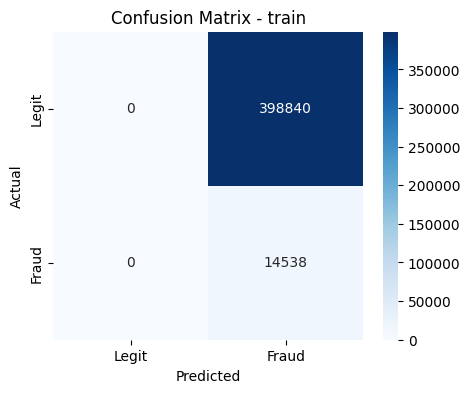

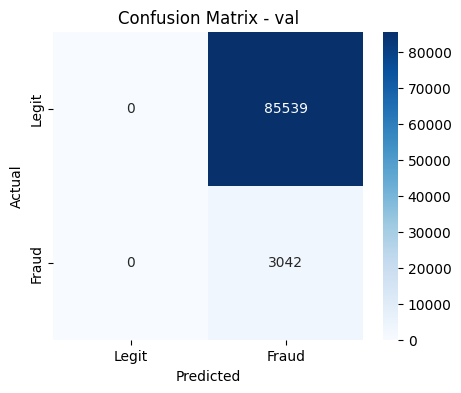

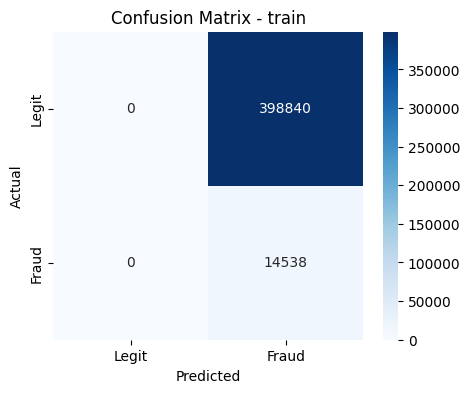

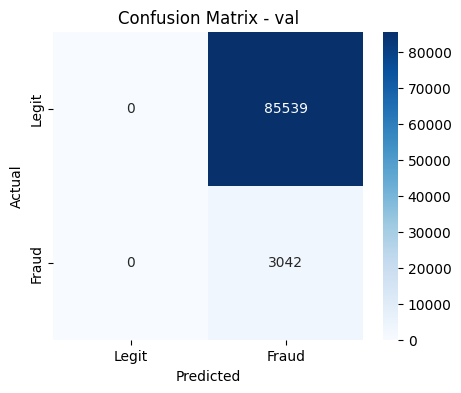

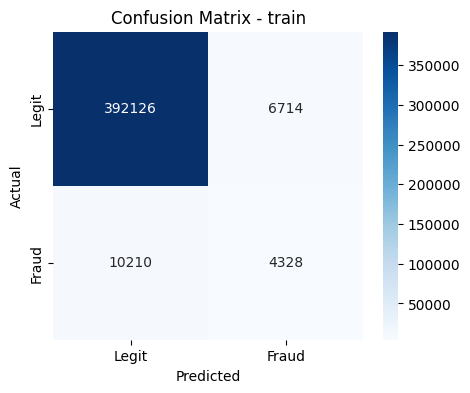

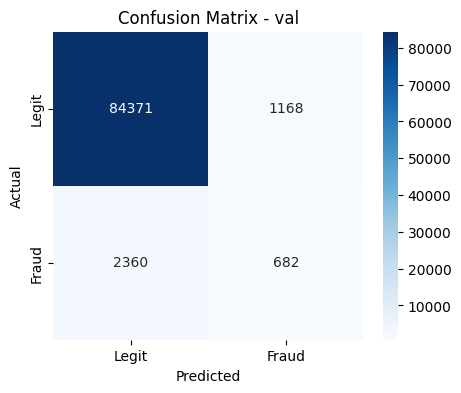

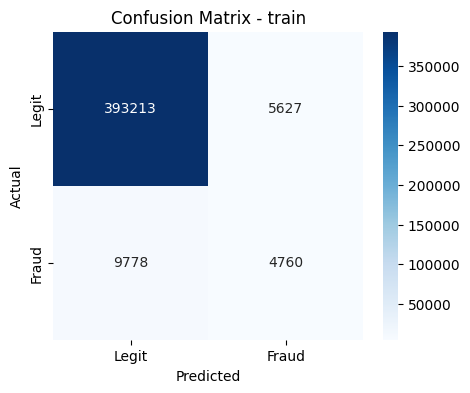

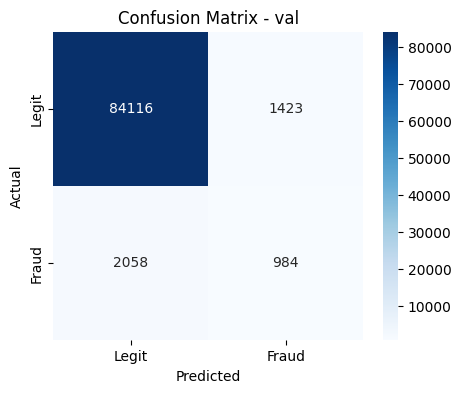

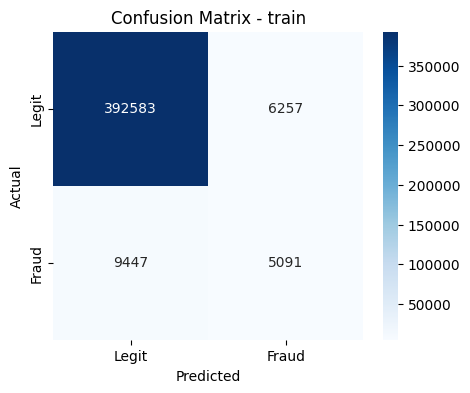

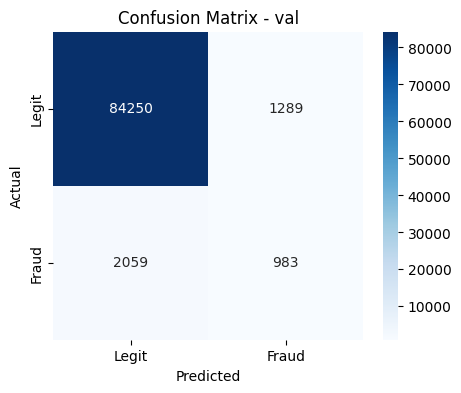

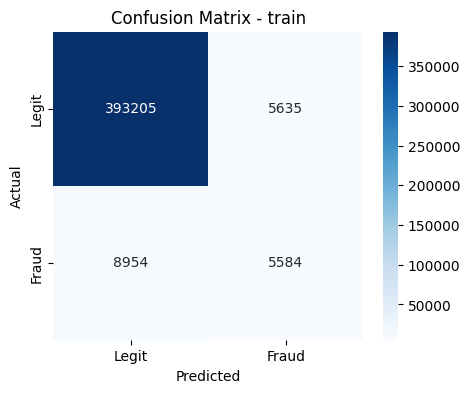

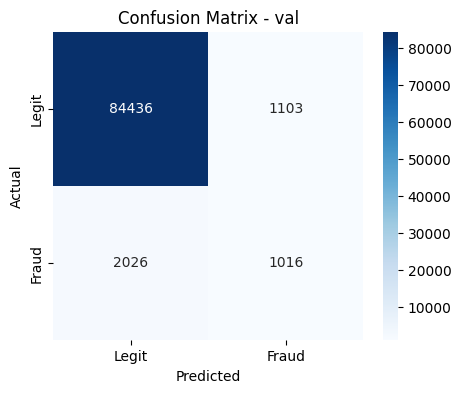

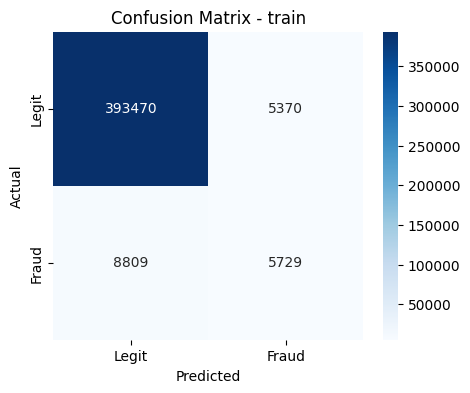

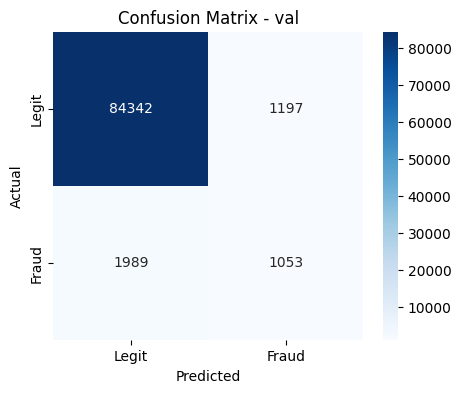

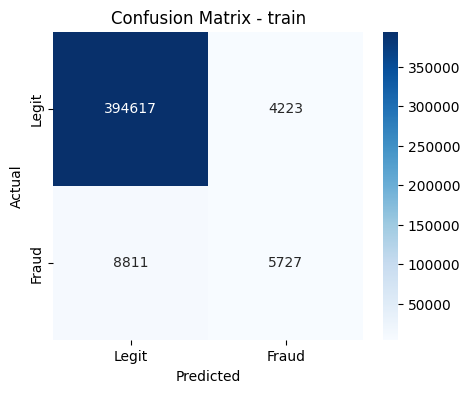

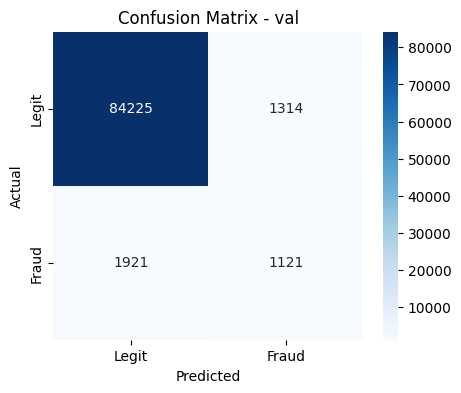

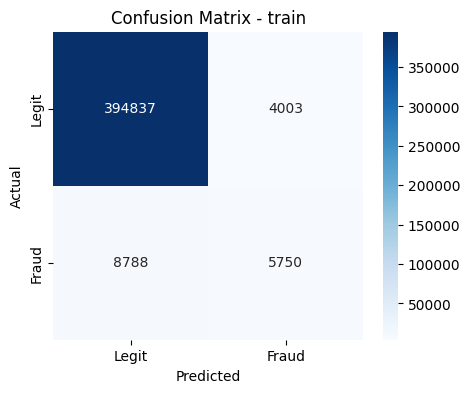

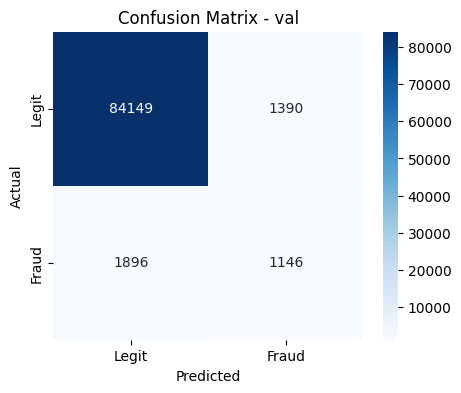

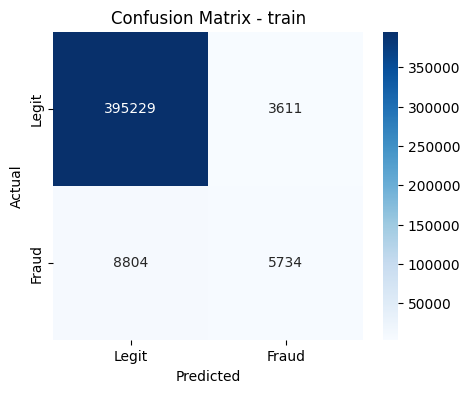

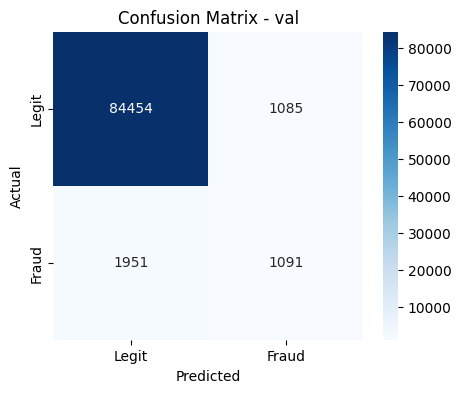

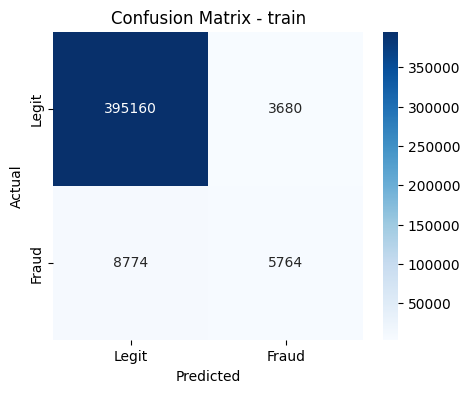

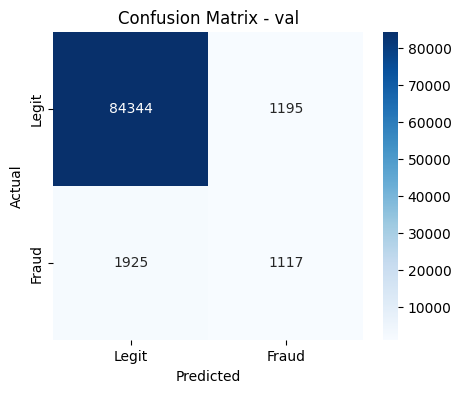

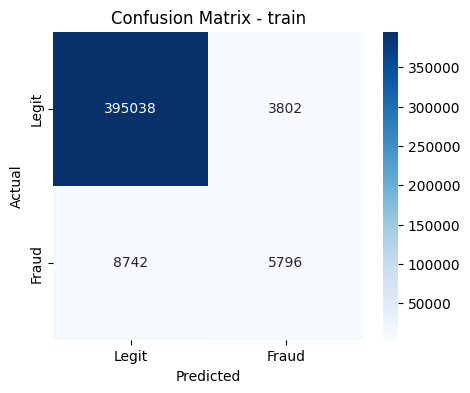

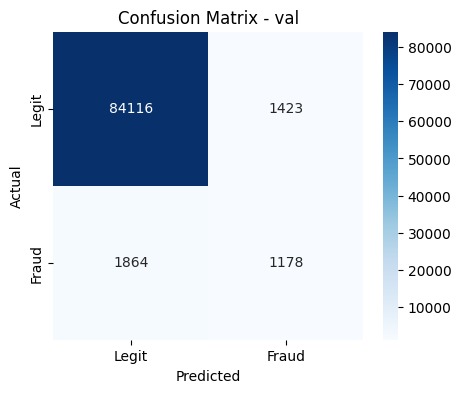

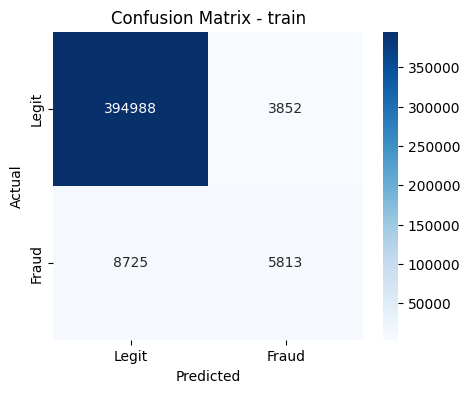

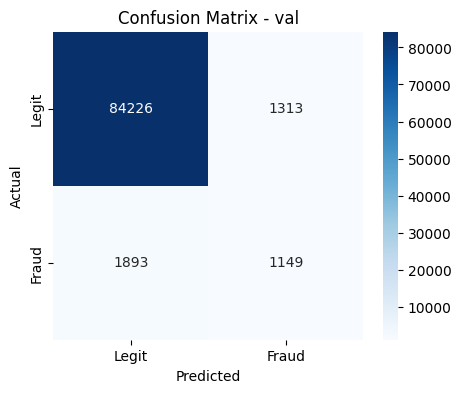

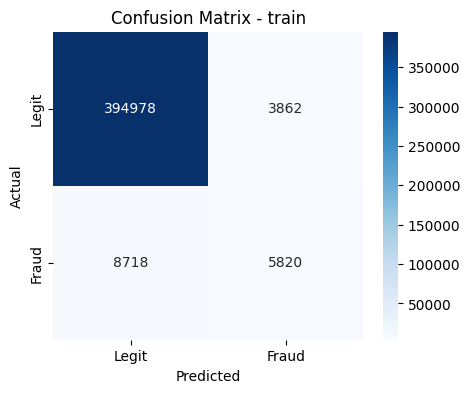

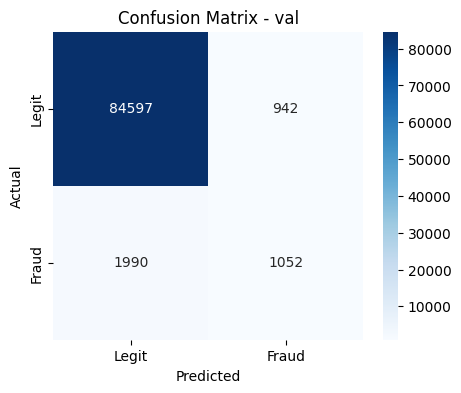

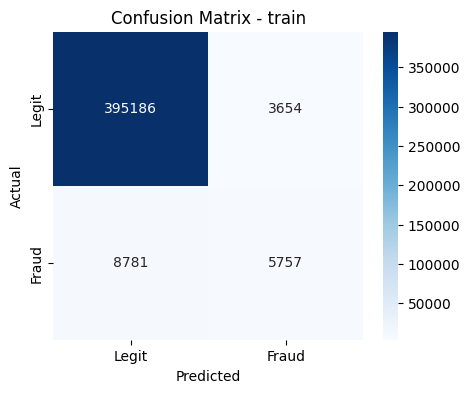

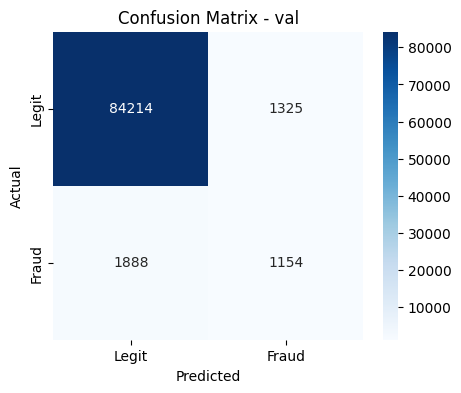

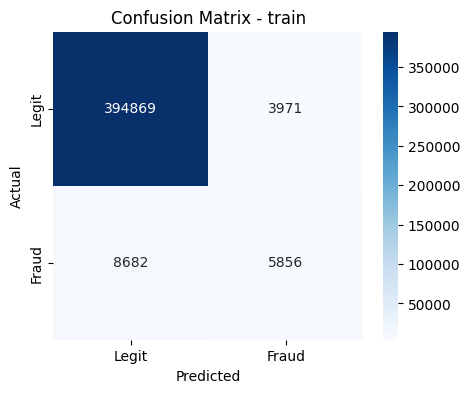

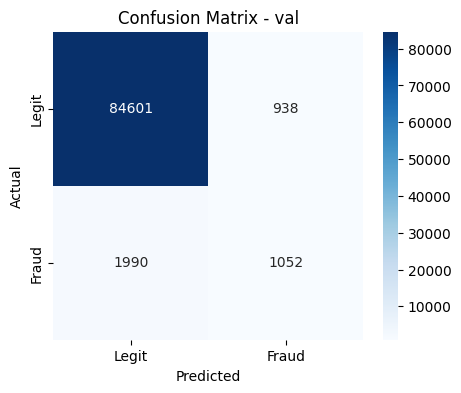

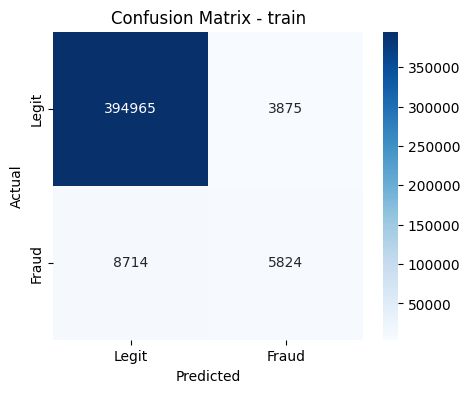

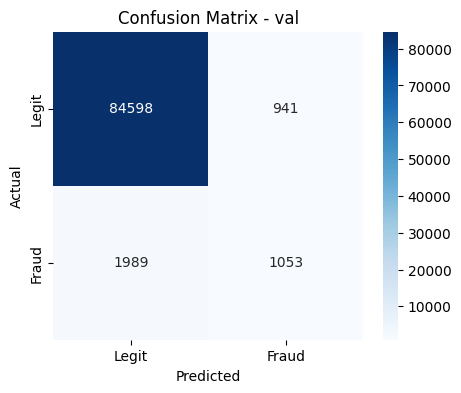

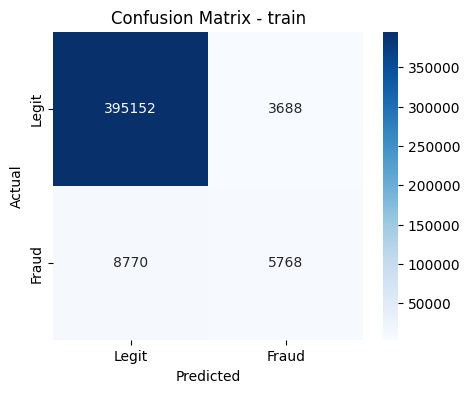

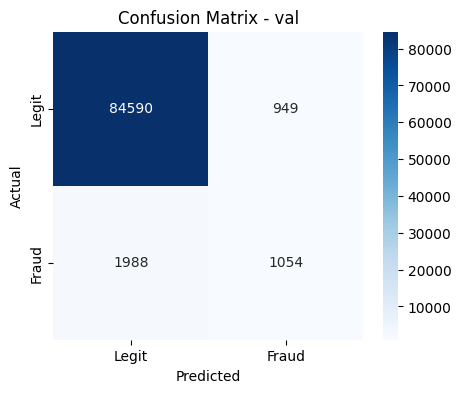

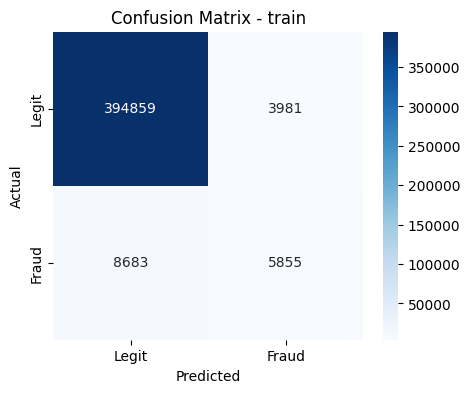

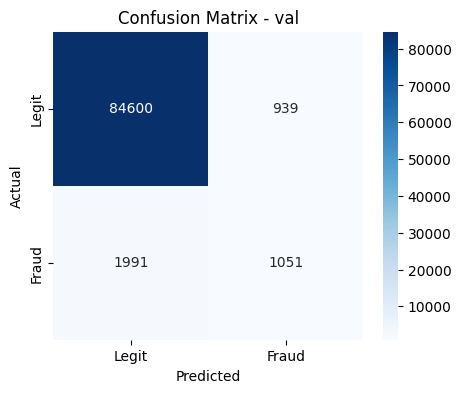

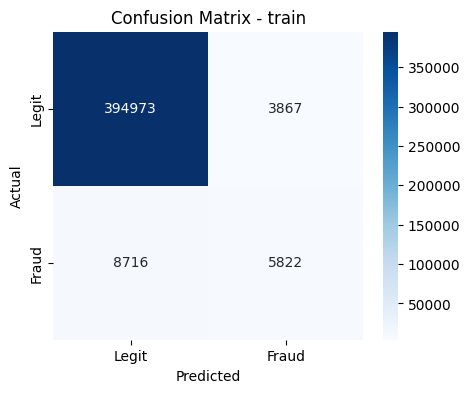

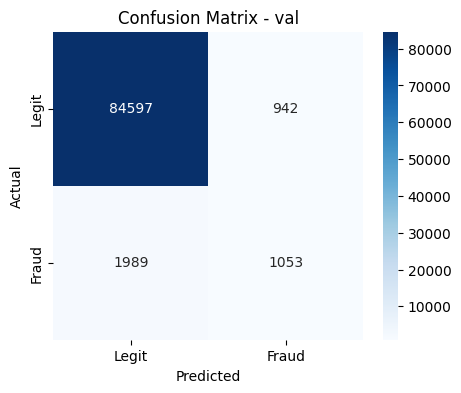

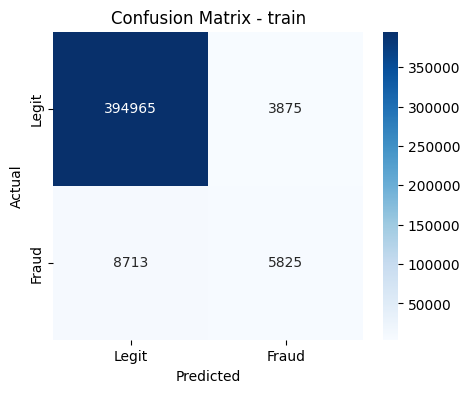

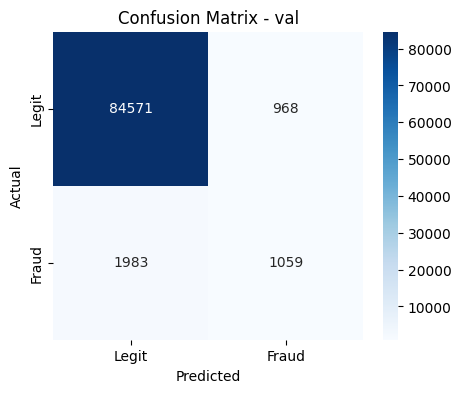

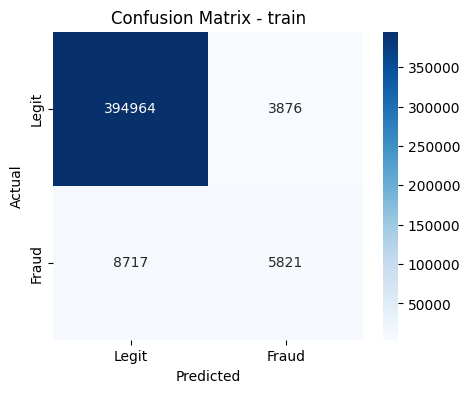

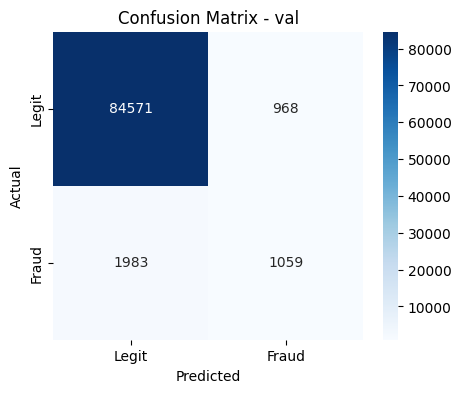

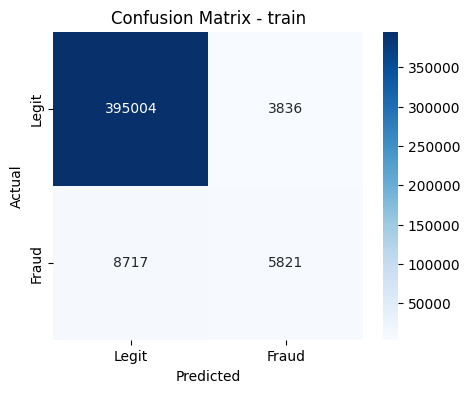

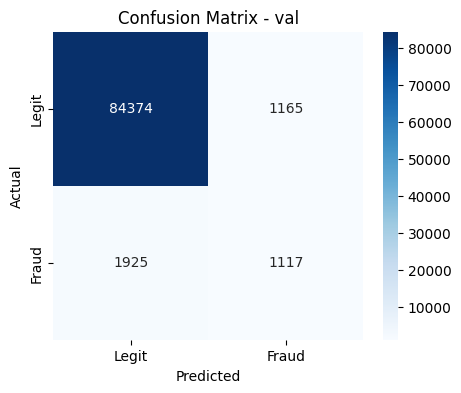

In [69]:
from sklearn.model_selection import ParameterGrid, GridSearchCV
from sklearn.base import clone


for prep_param in ParameterGrid(preprocessor_configs):
    num_impute_strategy = prep_param['prep__num__imputer__strategy'] 
    
    experiment_name = (
        f'IEEE-CIS_Fraud_Detection_Logistic_Regression_Training'
        f'__prep_v0'
        f'__num_impute_strategy_{num_impute_strategy}'
    )
    
    mlflow.set_experiment(experiment_name)
    
    preprocessor = clone(full_pipeline.named_steps['preprocessor'])
    preprocessor.set_params(**prep_param)

    print('Starting fitting & transforming X_train, X_val...')
    
    X_train_t = preprocessor.fit_transform(X_train, y_train)
    print('fit_transform X_train finished...')

    X_val_t   = preprocessor.transform(X_val)
    print('transform X_val finished...')

    print(prep_param)
    with mlflow.start_run(run_name='LR_Cleaning'):
        
        # Logging cleaning parameters
        mlflow.log_param('irrelevant_cols',              str(irrelevant_cols))
        mlflow.log_param('n_irrelevant_cols_dropped',    len(irrelevant_cols))
        mlflow.log_param('num_imputer_strategy',         prep_param['prep__num__imputer__strategy'])
        mlflow.log_param('cat_imputer_strategy',         prep_param['prep__cat__imputer__strategy'])
        mlflow.log_param('cat_imputer_fill_value',       prep_param['prep__cat__imputer__fill_value'])
        mlflow.log_param('cat_encoder_smooth',           prep_param['prep__cat__encoder__smooth'])
        mlflow.log_param('cat_encoder',                  'TargetEncoder')
        mlflow.log_param('scaler',                       'StandardScaler')

        # Logging cleaning metrics
        mlflow.log_metric('X_train_rows_before', X_train.shape[0])
        mlflow.log_metric('X_train_cols_before', X_train.shape[1])
        mlflow.log_metric('X_train_cols_after',  X_train_t.shape[1])
        mlflow.log_metric('X_val_rows_before',   X_val.shape[0])
        mlflow.log_metric('X_val_cols_before',   X_val.shape[1])
        mlflow.log_metric('X_val_cols_after',    X_val_t.shape[1])
        mlflow.log_metric('fraud_rate_train',    y_train.mean())
        mlflow.log_metric('fraud_rate_val',      y_val.mean())
        mlflow.log_metric('null_rate_train',     X_train.isnull().mean().mean())
        mlflow.log_metric('fraud_rate_train',    y_train.mean())
        mlflow.log_metric('fraud_rate_val',      y_val.mean())

    
    for model_param in ParameterGrid(model_configs):    
        cuml_model = clone(full_pipeline.named_steps['model'])
        cuml_model.set_params(**model_param)

        print('Currently running model with params:', model_param)
        
        print('Starting training model on X_train_t...')
        cuml_model.fit(X_train_t, y_train)
        print('Finished training model on X_train_t...')

        print('Starting predicting on X_train_t...')
        y_train_prob = cuml_model.predict_proba(X_train_t).iloc[:, 1]
        print('Finished predicting on X_train_t...')
        
        print('Starting predicting on X_val_t...')
        y_val_prob   = cuml_model.predict_proba(X_val_t).iloc[:, 1]
        print('Finished predicting on X_val_t...')
        
        print('train_roc_score:', roc_auc_score(y_train, y_train_prob))
        print('val_roc_score:',   roc_auc_score(y_val,   y_val_prob))

        sklearn_model = cuml_model.as_sklearn()
        preds = sklearn_model.predict_proba(X_val_t)[:, 1]
        print(preds[:5])
        print(y_val_prob[:5])

        # continue
        
        # Prepare for logging
        C            = model_param['C']
        l1_ratio     = model_param['l1_ratio']
        penalty      = model_param['penalty']
        solver       = model_param['solver']
        class_weight = model_param['class_weight']
        max_iter     = model_param['max_iter']
        # random_state = model_param['random_state']
        
        run_name = (
            f'LR_Training'
            f'__C_{C}'
            f'__l1_ratio_{l1_ratio}'
            f'__penalty_{penalty}'
            f'__solver_{solver}'
            f'__class_weight_{class_weight}'
        )

        # Start logging
        with mlflow.start_run(run_name=run_name):
            print('Logging model training results on mlflow...')

            print('Logging model parameters...')
            for key, val in model_param.items():
                mlflow.log_param(key, val)
            
            log_model_parameters_metrics(y_train, y_train_prob, 'train')
            log_model_parameters_metrics(y_val,   y_val_prob,   'val')
            
            log_model_metrics_curves(y_train, y_train_prob, 'train')
            log_model_metrics_curves(y_val,   y_val_prob,   'val')

            # Log full pipeline
            full_pipe = Pipeline([
                ('preprocessor', preprocessor),
                ('model',        sklearn_model)
            ])
            
            model_info = mlflow.sklearn.log_model(
                sk_model=full_pipe,
                artifact_path='pipeline'
            )
            
            mlflow.set_tag('model_id', model_info.model_id)
            mlflow.set_tag('model_type', 'LogisticRegression')

            # Loggin feature importances
            feature_names = X_train_t.columns.tolist()
            coefs = np.abs(sklearn_model.coef_[0])
            
            importance_df = pd.DataFrame({
                'feature':    feature_names,
                'importance': coefs
            }).sort_values('importance', ascending=False)
            
            importance_df.to_csv('feature_importance.csv', index=False)
            mlflow.log_artifact('feature_importance.csv')